# Previsão do Volume de Atendimentos do Pronto-Socorro com Suavização Exponencial (PROC ESM)


## Resumo executivo

Um sistema hospitalar de médio porte precisa de uma previsão de um ano à frente do volume mensal de atendimentos do pronto-socorro (PS) para planejar a escala de enfermagem e a capacidade de leitos antes do pico respiratório do inverno. Este notebook constrói um censo mensal sintético de quatro anos do PS (48 meses, jan 2021 - dez 2024) e ajusta um modelo sazonal multiplicativo de Winters com **PROC ESM** para produzir uma previsão de 12 meses com intervalos de predição de 95%.

O modelo ajustado captura bem a série: o **RMSE dentro da amostra é de cerca de 320 atendimentos** e o **MAPE é 4.16%**, de modo que o erro mensal típico fica abaixo de 5% do volume. A previsão projeta a forma sazonal familiar para 2025 - um pico de dezembro a fevereiro perto de **7.300-7.800 atendimentos/mês** e um vale de fim de verão perto de **5.800-5.900** - com bandas de predição que se alargam à medida que o horizonte se estende. Esses números, e os pesos de suavização por trás deles, são lidos diretamente dos conjuntos de dados de saída do procedimento abaixo.


## Fontes de dados

| Conjunto de dados | Linhas | Granularidade | Variáveis-chave | Descrição |
|---------|------|-------|---------------|-------------|
| `ed_census` | 48 | Uma linha por mês calendário, jan 2021 - dez 2024 | `month` (data SAS mensal), `ed_visits` (contagem inteira mensal de atendimentos do PS) | Volume sintético mensal de atendimentos do pronto-socorro para um sistema hospitalar de médio porte. Gerado com uma tendência de crescimento ascendente (~3% ao ano), um ciclo sazonal multiplicativo com pico na temporada respiratória de inverno (dez-fev) e queda no fim do verão, mais ruído log-normal para que a amplitude sazonal escale com o nível ascendente. |


# Previsão do Volume de Atendimentos do Pronto-Socorro com PROC ESM

Os planejadores de capacidade precisam saber quantos atendimentos do PS esperar a cada mês para poder escalar enfermeiros, reservar leitos flexíveis e preparar insumos respiratórios antes do pico do inverno. O volume do PS é uma série temporal sazonal de manual: cresce lentamente ano após ano, atinge o pico durante a temporada respiratória de dezembro a fevereiro e recua no fim do verão, e o tamanho da oscilação sazonal cresce à medida que o volume de base cresce. Essa estrutura sazonal multiplicativa é exatamente o que o método multiplicativo de Winters no **PROC ESM** foi projetado para capturar.

Neste notebook nós:

1. Geramos um censo mensal realista de quatro anos do PS com tendência, sazonalidade multiplicativa e ruído.
2. Visualizamos a série para confirmar sua estrutura sazonal multiplicativa.
3. Ajustamos um modelo multiplicativo de Winters com PROC ESM e lemos seus pesos de suavização e estatísticas de ajuste dos conjuntos de dados de saída.
4. Produzimos uma previsão de 12 meses à frente com intervalos de predição de 95% e interpretamos as implicações operacionais.


## Passo 1 - Gerar o censo mensal sintético do PS

Construímos 48 observações mensais de janeiro de 2021 a dezembro de 2024. O volume esperado de cada mês é um nível de base que cresce cerca de 3% ao ano, multiplicado por um índice sazonal (mais alto no meio do inverno, mais baixo no fim do verão), depois perturbado por ruído log-normal para que a variação aleatória escale com o nível. `intnx` avança a data alinhada ao mês em um período por linha, e `streaminit` torna o sorteio reprodutível.


In [1]:
DADOS ed_census;
    CHAMAR streaminit(20240531);
    /* Monthly seasonal index: peaks Dec-Feb (flu/RSV), troughs Aug-Sep */
    VETOR seas{12} _temporary_
        (1.18 1.14 1.05 0.97 0.93 0.90 0.92 0.86 0.88 0.97 1.06 1.14);
    FORMATO month yymmn6.;
    FAZER i = 1 ATÉ 48;
        month = intnx('month', '01JAN2021'd, i - 1);
        m = month(month);
        /* Baseline ~6000 visits/mo growing ~3% per year */
        level = 6000 * (1.03 ** ((i - 1) / 12));
        /* Multiplicative seasonality + level-scaled lognormal noise */
        noise = EXP(rand('normal', 0, 0.035));
        ed_visits = round(level * seas{m} * noise);
        SAÍDA;
    FIM;
    MANTER month ed_visits;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=ed_census(obs=14) noobs RÓTULO;
    RÓTULO month = "Mês" ed_visits = "Atendimentos do PS";
    TÍTULO "Primeiros 14 meses do volume sintético de atendimentos do PS";
EXECUTAR;

                              Primeiros 14 meses do volume sintético de atendimentos do PS                              

   Mês  Atendimentos do PS
202101                7103
202102                6835
202103                6668
202104                5611
202105                5816
202106                5383
202107                5586
202108                5283
202109                5161
202110                6109
202111                6451
202112                6730
202201                6847
202202                7213

... 34 more observations (showing 14 of 48)




NOTE: DATA ed_census


NOTE: Wrote ed_census (48 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ed_census

NOTE: PROC PRINT completed: 14 observations printed, 2 variables


Os primeiros meses confirmam o desenho: o volume abre perto de 7.100 no pico de janeiro de 2021, cai ao longo da primavera e do verão até seu vale de agosto-setembro, depois volta a subir rumo ao inverno seguinte. Em janeiro de 2022 o pico subiu para cerca de 6.800-7.200, refletindo o crescimento anual de ~3% sobreposto ao ciclo sazonal.


## Passo 2 - Visualizar a série

Antes de modelar, plote a série bruta para confirmar a estrutura que esperamos: uma tendência ascendente suave com um pico anual repetido a cada inverno cuja amplitude se alarga ao longo do tempo. Uma oscilação sazonal que se alarga é a assinatura de um processo sazonal *multiplicativo* e nos diz qual modelo ESM escolher.


                              Primeiros 14 meses do volume sintético de atendimentos do PS                              




NOTE: PROC SGPLOT data=ed_census

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


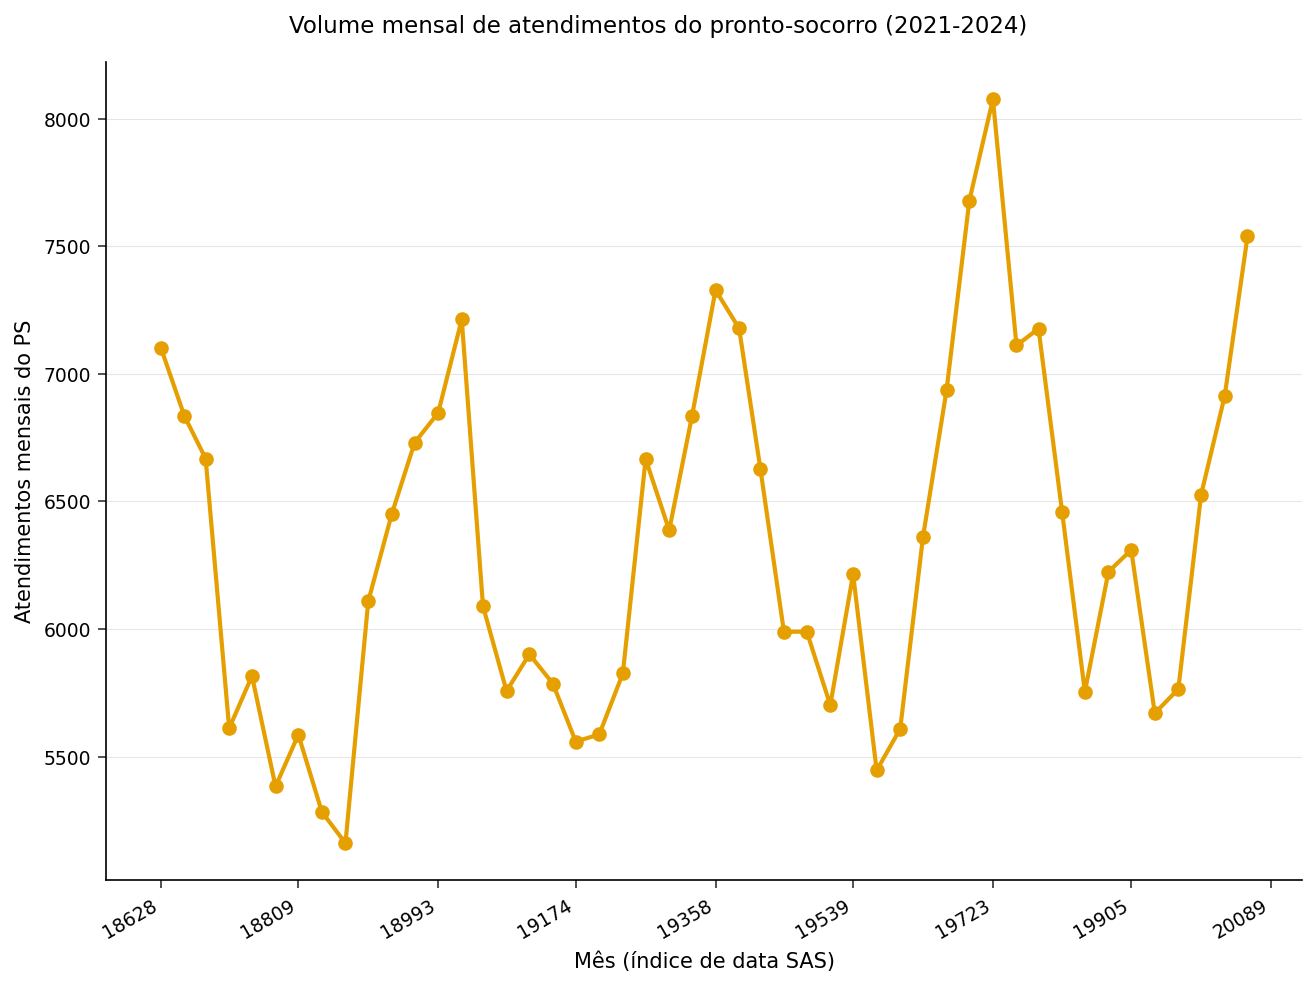

In [2]:
PROCEDIMENTO SGPLOT DADOS=ed_census;
    SERIES x=month y=ed_visits / MARKERS
        MARKERATTRS=(SYMBOL=circlefilled)
        LINEATTRS=(thickness=2);
    XAXIS RÓTULO="Mês (índice de data SAS)";
    YAXIS RÓTULO="Atendimentos mensais do PS" grid;
    TÍTULO "Volume mensal de atendimentos do pronto-socorro (2021-2024)";
EXECUTAR;

O gráfico mostra quatro ciclos anuais nítidos. Cada pico de inverno fica um pouco mais alto que o anterior, subindo de cerca de 7.100 em 2021 para cerca de 8.100 no pico de 2024, enquanto os vales de verão sobem de forma mais modesta - a oscilação sazonal cresce com o nível. Essa amplitude que se alarga é a marca da sazonalidade multiplicativa e justifica `MODEL=WINTERS` (Winters multiplicativo) no próximo passo.


## Passo 3 - Ajustar o modelo multiplicativo de Winters

Ajustamos a suavização sazonal multiplicativa de Winters sobre todo o histórico de 48 meses. A instrução `ID` declara `month` como o índice temporal em um intervalo `MONTH`, e a instrução `FORECAST` solicita `MODEL=WINTERS` com `LEAD=12` para projetar um ano à frente. Capturamos três conjuntos de dados de saída:

- `OUT=` - a série histórica com a previsão anexada (uma coluna `ed_visits`), com o ID temporal estendido ao longo do horizonte de previsão - ideal para plotagem.
- `OUTFOR=` - os componentes de previsão por período: previsão pontual (`PREDICT`) e os limites de predição inferior/superior.
- `OUTSUM=` - as estatísticas de ajuste do modelo (RMSE, MAE, MAPE, AIC) e os pesos de suavização, em uma única linha de resumo.

`ALPHA=0.05` gera limites de predição de 95%, apropriados para as margens de risco do planejamento de capacidade. `PRINT=(STATISTICS)` ecoa as estatísticas de ajuste e os pesos de suavização para o listing.


In [3]:
PROCEDIMENTO esm DADOS=ed_census
        LEAD=12
        out=ed_with_forecast
        outfor=esm_forecast
        outsum=esm_summary
        IMPRIMIR=(statistics);
    id month interval=month;
    forecast ed_visits / MODELO=winters ALPHA=0.05;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=esm_summary noobs RÓTULO;
    RÓTULO rmse="RMSE" mae="MAE" mape="MAPE"
          ALPHA="Nível (alfa)" beta="Tendência (beta)" gamma="Sazonal (gama)";
    VARIÁVEL rmse mae mape ALPHA beta gamma;
    TÍTULO "Estatísticas de ajuste de Winters e pesos de suavização";
EXECUTAR;

                              Primeiros 14 meses do volume sintético de atendimentos do PS                              


Exponential Smoothing Forecast for ed_visits
Method: WINTERS
Number of Observations: 48
Forecast Periods: 12

Fit Statistics:
  RMSE     = 320.4349
  MAE      = 264.4440
  MAPE     = 4.1597
  MSE      = 102678.4971
  AIC      = 421.4169

Smoothing Weights:
  ALPHA      = 0.3000
  BETA       = 0.1000
  GAMMA      = 0.1000

Forecasts:
  Period     Predict        
  1          7822.1805      
  2          7538.7511      
  3          7291.7885      
  4          6262.7158      
  5          6396.7222      
  6          6039.1562      
  7          6235.5688      
  8          5867.3108      
  9          5801.6677      
  10         6803.9608      
  11         7172.6105      
  12         7566.8263      



                                Estatísticas de ajuste de Winters e pesos de suavização                                 

          RMSE            MAE         MA


NOTE: PROC ESM data=ed_census

NOTE: Using Python for ESM estimation
NOTE: Output dataset ED_WITH_FORECAST created with 60 observations.
NOTE: Output dataset ESM_FORECAST created with 60 observations.
NOTE: PROC PRINT data=esm_summary

NOTE: PROC PRINT completed: 1 observations printed, 6 variables


A linha `OUTSUM=` e as estatísticas impressas concordam: o ajuste multiplicativo de Winters alcança um **RMSE dentro da amostra de 320.4 atendimentos**, **MAE de 264.4** e **MAPE de 4.16%** - um erro mensal típico bem abaixo de 5% do volume, o que é confortavelmente preciso para o planejamento de escalas. Os pesos de suavização são **alpha = 0.30** (nível), **beta = 0.10** (tendência) e **gamma = 0.10** (sazonalidade). O peso moderado de nível permite que a base derive para cima com o crescimento da população de pacientes, enquanto os pequenos pesos de tendência e sazonalidade refletem que a taxa de crescimento e a forma do pico de inverno são estáveis de ano para ano e não devem ser sobre-reagidos de mês a mês.

> Observação: estas são estatísticas de ajuste *dentro da amostra* calculadas sobre a amostra de estimação, não uma validação fora da amostra (holdout). Elas quantificam quão de perto o modelo acompanha o histórico sobre o qual foi ajustado.


## Passo 4 - Montar e tabular a previsão de 12 meses

O conjunto de dados `OUTFOR=` contém a previsão pontual e os limites de predição para cada período, enquanto o conjunto de dados `OUT=` carrega o ID temporal estendido de forma limpa ao longo do horizonte de previsão. Alinhamos os dois pela ordem das observações para anexar as datas de previsão aos limites de predição, depois mantemos apenas os 12 meses de previsão. Estes são os números sobre os quais um comitê de escalas atuaria.


In [4]:
/* OUT= carries the forecast-horizon dates; OUTFOR= carries the
   prediction limits. Align them by observation order to put dates on
   the limits, then keep only the 12 forecast months.            */
DADOS out_idx;
    DEFINIR ed_with_forecast;
    row = _n_;
    RENOMEAR month = fdate ed_visits = series_value;
EXECUTAR;

DADOS for_idx;
    DEFINIR esm_forecast;
    row = _n_;
    RENOMEAR ed_visits = observed;
    MANTER row observed predict LOWER UPPER;
EXECUTAR;

DADOS forecast_path;
    MESCLAR out_idx for_idx;
    POR row;
    FORMATO fdate yymmn6. series_value observed predict LOWER UPPER comma8.0;
EXECUTAR;

DADOS forecast_horizon;
    DEFINIR forecast_path;
    ONDE observed = .;   /* forecast months only (no observed value) */
    MANTER fdate predict LOWER UPPER;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=forecast_horizon noobs RÓTULO;
    RÓTULO fdate   = "Mês"
          predict = "Atendimentos previstos"
          LOWER   = "Inferior 95%"
          UPPER   = "Superior 95%";
    TÍTULO "Previsão de 12 meses de atendimentos do PS com limites de predição de 95%";
EXECUTAR;

                       Previsão de 12 meses de atendimentos do PS com limites de predição de 95%                        

   Mês  Atendimentos previstos  Inferior 95%  Superior 95%
202501                   7,822         7,194         8,450
202502                   7,539         6,651         8,427
202503                   7,292         6,204         8,380
202504                   6,263         5,007         7,519
202505                   6,397         4,992         7,801
202506                   6,039         4,501         7,578
202507                   6,236         4,574         7,897
202508                   5,867         4,091         7,644
202509                   5,802         3,918         7,686
202510                   6,804         4,818         8,790
202511                   7,173         5,090         9,256
202512                   7,567         5,391         9,742




NOTE: DATA out_idx


NOTE: Read 60 rows from ed_with_forecast.
NOTE: Wrote out_idx (60 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA for_idx


NOTE: Read 60 rows from esm_forecast.
NOTE: Wrote for_idx (60 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_path

NOTE: Stream 1 processed 60 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 60 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote forecast_path (60 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA forecast_horizon


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_horizon (12 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=forecast_horizon

NOTE: PROC PRINT completed: 12 observations printed, 4 variables


A previsão leva a assinatura sazonal adiante para 2025. O modelo projeta o pico de janeiro de 2025 em cerca de **7.822 atendimentos** (intervalo de 95% 7.194-8.450), afrouxa ao longo da primavera, atinge o fundo no vale de fim de verão perto de **5.802** em setembro (intervalo 3.918-7.686), depois recompõe-se rumo a um pico de dezembro de cerca de **7.567** (intervalo 5.391-9.742). A banda de predição alarga-se de forma constante com o horizonte - o intervalo do próximo mês abrange cerca de +/-630 atendimentos, enquanto o do próximo dezembro abrange mais de +/-2.000 - um lembrete direto de que os planos de curto prazo são muito mais firmes que os de fim de ano.


## Passo 5 - Plotar histórico mais previsão

Por fim, sobreponha a previsão ao histórico observado para que os planejadores possam ver o pico de inverno projetado e a banda de incerteza que se alarga à medida que o horizonte se estende. Dividimos a série alinhada `forecast_path` no histórico **observado** (linha sólida) e na **previsão de 12 meses** (tracejada) para que a transição fique clara, e desenhamos a banda de predição de 95% por baixo. O eixo x é o índice de data SAS mensal, correndo da esquerda para a direita de jan 2021 a dez 2025.


                       Previsão de 12 meses de atendimentos do PS com limites de predição de 95%                        




NOTE: DATA forecast_plot


NOTE: Read 60 rows from forecast_path.
NOTE: Wrote forecast_plot (60 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=forecast_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


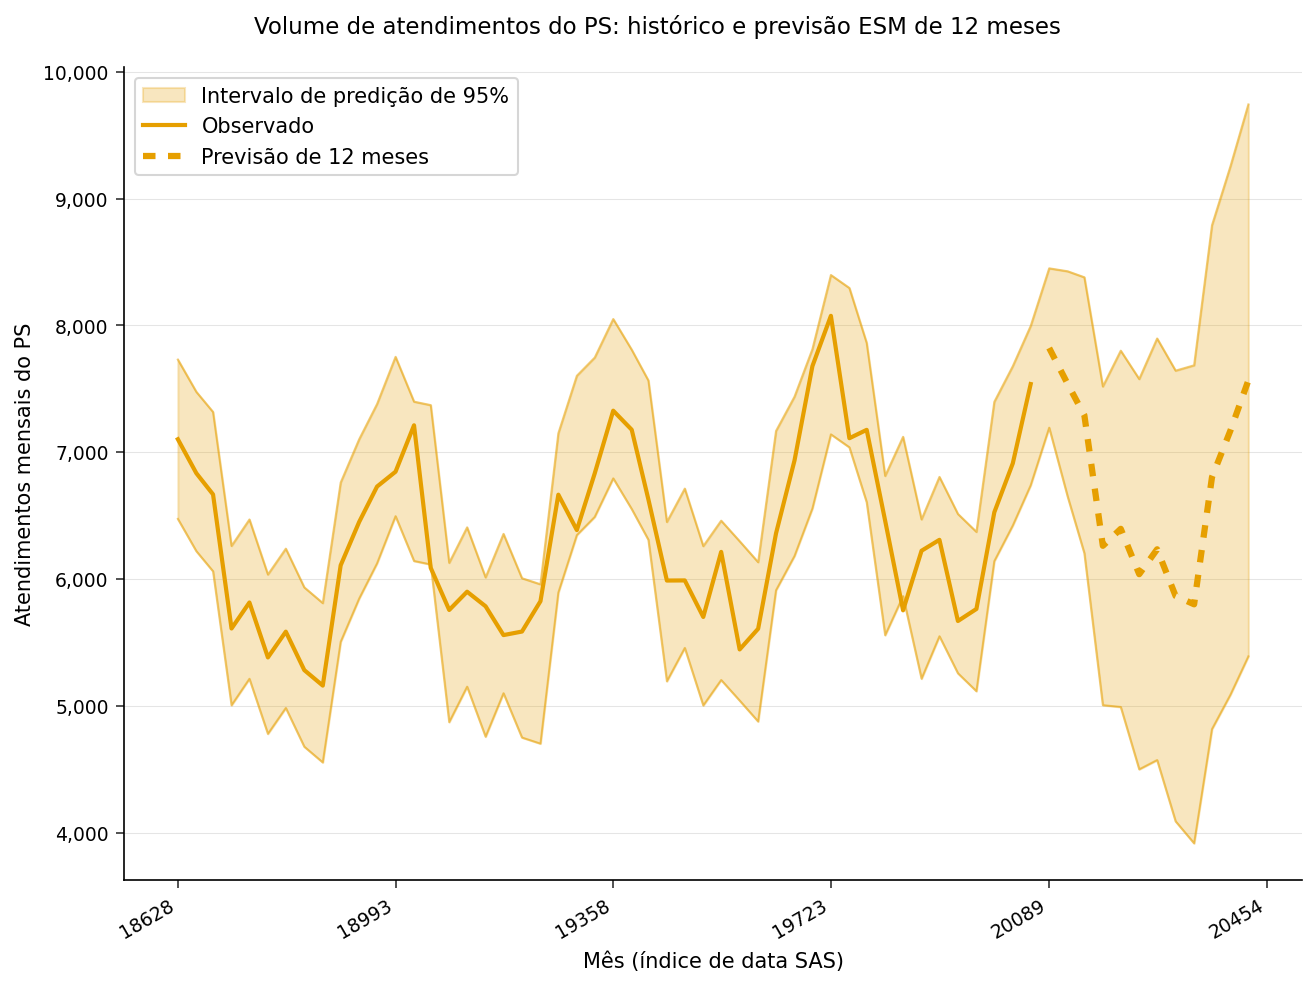

In [5]:
/* Split the projected series into the observed history and the
   12-month forecast so they render with distinct styling, and overlay
   the 95% prediction band from the aligned forecast_path dataset.   */
DADOS forecast_plot;
    DEFINIR forecast_path;
    SE observed = . ENTÃO fc_only = predict;   /* future months only */
    SENÃO fc_only = .;
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=forecast_plot;
    BAND x=fdate LOWER=LOWER UPPER=UPPER /
        legendlabel="Intervalo de predição de 95%" TRANSPARENCY=0.5;
    SERIES x=fdate y=observed / LINEATTRS=(thickness=2)
        legendlabel="Observado";
    SERIES x=fdate y=fc_only / LINEATTRS=(thickness=3 pattern=shortdash)
        legendlabel="Previsão de 12 meses";
    XAXIS RÓTULO="Mês (índice de data SAS)";
    YAXIS RÓTULO="Atendimentos mensais do PS" grid;
    TÍTULO "Volume de atendimentos do PS: histórico e previsão ESM de 12 meses";
EXECUTAR;

## Interpretando os resultados

O modelo multiplicativo de Winters decompõe o volume do PS em um **nível** que sobe lentamente, uma **tendência** quase plana e um padrão **sazonal** estável. Os pesos de suavização lidos de `OUTSUM=` contam a história: um peso de nível moderado (alpha = 0.30) permite que a base derive para cima com o crescimento da população de pacientes, enquanto os pequenos pesos de tendência e sazonalidade (beta = gamma = 0.10) refletem que a taxa de crescimento e a forma do pico de inverno são altamente estáveis de ano para ano e não devem ser sobre-reagidos de mês a mês.

As **estatísticas de ajuste** confirmam que o modelo acompanha bem o histórico: um RMSE de cerca de 320 atendimentos e um MAPE de 4.16% significam que o erro mensal típico fica abaixo de 5% do volume. Operacionalmente, a **tabela de previsão e o gráfico de bandas** quantificam o pico de dezembro a fevereiro para o qual o PS deve dimensionar sua equipe - cerca de 7.300-7.800 atendimentos nos meses de inverno - e os limites de predição de 95% definem uma faixa de capacidade prudente: planeje a escala básica pela previsão pontual e pré-organize cobertura flexível e leitos de surto rumo ao limite superior. O intervalo alarga-se com o horizonte, portanto o plano do próximo mês é muito mais firme que o do próximo dezembro e deve ser atualizado à medida que novos dados reais chegam.

**Extensões:** compare `MODEL=ADDWINTERS` (sazonalidade aditiva) com o ajuste multiplicativo para confirmar a escolha multiplicativa; aplique `TRANSFORM=LOG` para impor positividade e estabilizar a variância; ou adicione uma instrução `BY` para prever múltiplos locais hospitalares em uma única chamada de PROC ESM.
